In [1]:
! kaggle datasets download wangboluo/harhuman-activity-recognition-dataset-with-label

Dataset URL: https://www.kaggle.com/datasets/wangboluo/harhuman-activity-recognition-dataset-with-label
License(s): apache-2.0
100%|█████████████████████████████████████████| 296M/296M [00:01<00:00, 218MB/s]



In [2]:
! unzip -q harhuman-activity-recognition-dataset-with-label.zip -d /kaggle/working && echo "Unzipping completed successfully."

Unzipping completed successfully.


In [3]:
import tensorflow as tf
from tensorflow.keras import models, layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.regularizers import l2
from tensorflow.keras.models import Sequential
import matplotlib.pyplot as plt
from IPython.display import HTML
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Input, Dense, GlobalAveragePooling2D, InputLayer, Flatten, BatchNormalization, Dropout, MaxPooling2D, Conv2D, DepthwiseConv2D
import numpy as np
from PIL import Image
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import confusion_matrix
import os
import seaborn as sns
from sklearn.metrics import classification_report
from tensorflow.keras.layers import RandomFlip, RandomRotation, RandomZoom
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import LearningRateScheduler
from tensorflow.keras import regularizers
from tensorflow.keras.models import Model

2026-03-08 13:32:16.649874: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772976736.823505      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772976736.877311      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772976737.306664      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772976737.306700      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772976737.306703      55 computation_placer.cc:177] computation placer alr

In [4]:
IMAGE_SIZE = 128
BATCH_SIZE = 32

In [5]:
# def preprocess_image(image, label):
#     image = tf.image.resize(image, (IMAGE_SIZE, IMAGE_SIZE))
#     image = tf.keras.applications.resnet50.preprocess_input(image)  # IMPORTANT
#     return image, label

def preprocess_image(image, label):
    image = tf.image.resize(image, (IMAGE_SIZE, IMAGE_SIZE))
    image = tf.keras.applications.efficientnet.preprocess_input(image)
    return image, label

In [6]:
import tensorflow as tf

AUTOTUNE = tf.data.AUTOTUNE

# Original folders
train_path = "/kaggle/working/train"
test_path = "/kaggle/working/test"

# Load both datasets
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_path,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=123
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_path,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=123
)

# Merge datasets
full_dataset = train_ds.concatenate(test_ds)

# Shuffle merged dataset
full_dataset = full_dataset.shuffle(10000, seed=123)

# Compute dataset size
dataset_size = tf.data.experimental.cardinality(full_dataset).numpy()
train_size = int(0.80 * dataset_size)

# Split 
train_dataset = full_dataset.take(train_size)
test_dataset = full_dataset.skip(train_size)

# Apply preprocessing
train_dataset = train_dataset.map(preprocess_image, num_parallel_calls=AUTOTUNE)
test_dataset = test_dataset.map(preprocess_image, num_parallel_calls=AUTOTUNE)

# Optimize pipeline
train_dataset = train_dataset.prefetch(AUTOTUNE)
test_dataset = test_dataset.prefetch(AUTOTUNE)

print("Train batches:", train_size)
print("Test batches:", dataset_size - train_size)

Found 12600 files belonging to 15 classes.


I0000 00:00:1772976764.417633      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1772976764.423579      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 5400 files belonging to 15 classes.
Train batches: 450
Test batches: 113


In [7]:
for image_batch, labels_batch in train_dataset.take(1):
    print(image_batch.shape)
    print(labels_batch.numpy())

(32, 128, 128, 3)
[ 6 11  0 14  2  3  5  4 10  8 10  5  9 12  7  7 12 10  6 11 11 11 13 14
  5  4 14  1  1  6 11  4]


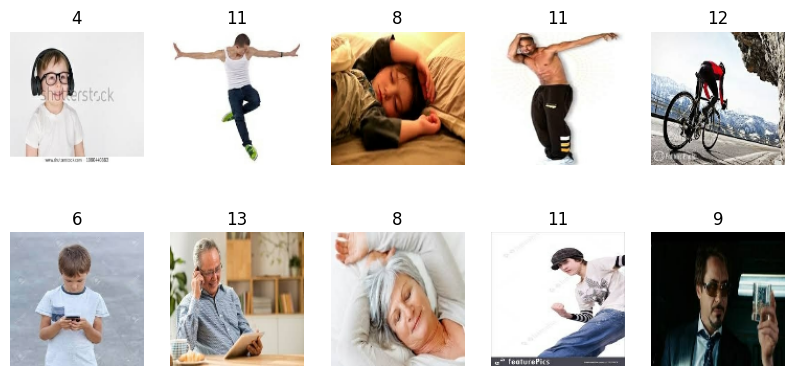

In [8]:
for images, labels in train_dataset.take(1):
    plt.figure(figsize=(10, 10))

    num_images = min(10, images.shape[0])

    for i in range(num_images):
        ax = plt.subplot(4, 5, i + 1)
        img = images[i].numpy()

        if img.min() < 0 or img.max() > 1:
            img = ((img - img.min()) / (img.max() - img.min()) * 255).astype("uint8")
        else:
            img = (img * 255).astype("uint8")

        plt.imshow(img)
        plt.title(int(labels[i]))
        plt.axis("off")

    plt.show()
    break

In [9]:
def get_dataset_partitions_tf(ds, train_split=0.80, val_split=0.20, shuffle=True, shuffle_size=10000):

    assert (train_split + val_split) == 1

    ds_size = tf.data.experimental.cardinality(ds).numpy()

    if shuffle:
        ds = ds.shuffle(shuffle_size, seed=12)

    train_size = int(train_split * ds_size)

    train_ds = ds.take(train_size)
    val_ds = ds.skip(train_size)

    return train_ds, val_ds


train_ds, val_ds = get_dataset_partitions_tf(train_dataset)

train_ds = train_ds.shuffle(1000).cache().prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.cache().prefetch(tf.data.AUTOTUNE)
test_ds = test_dataset.cache().prefetch(tf.data.AUTOTUNE)

In [10]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers

def build_alexnet_model(num_classes=15, input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3)):

    # Augmentation
    augment = tf.keras.Sequential([
        layers.RandomFlip("horizontal_and_vertical"),
        layers.RandomRotation(0.2),
        layers.RandomContrast(0.3),
        layers.RandomBrightness(0.2),
    ])

    inputs = layers.Input(shape=input_shape)
    x = augment(inputs)

    # AlexNet backbone
    x = layers.Conv2D(96, kernel_size=11, strides=4, activation="relu", padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(pool_size=3, strides=2)(x)

    x = layers.Conv2D(256, kernel_size=5, activation="relu", padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(pool_size=3, strides=2)(x)

    x = layers.Conv2D(384, kernel_size=3, activation="relu", padding="same")(x)
    x = layers.Conv2D(384, kernel_size=3, activation="relu", padding="same")(x)
    x = layers.Conv2D(256, kernel_size=3, activation="relu", padding="same")(x)
    x = layers.MaxPooling2D(pool_size=3, strides=2)(x)

    # Squeeze & Excitation
    se = layers.GlobalAveragePooling2D()(x)
    se = layers.Reshape((1, 1, x.shape[-1]))(se)
    se = layers.Dense(x.shape[-1] // 16, activation='relu')(se)
    se = layers.Dense(x.shape[-1], activation='sigmoid')(se)
    x = layers.Multiply()([x, se])

    # Multi-path pooling
    gap = layers.GlobalAveragePooling2D()(x)
    gmp = layers.GlobalMaxPooling2D()(x)
    flattened = layers.Concatenate()([gap, gmp])

    # Classifier head (same as other models)
    x = layers.Dense(1024, kernel_regularizer=regularizers.l2(1e-4))(flattened)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("gelu")(x)
    x = layers.Dropout(0.3)(x)

    outputs = layers.Dense(num_classes, activation="softmax")(x)

    return models.Model(inputs, outputs)


model = build_alexnet_model()

In [11]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 128, 128,  │          0 │ input_layer[0][0] │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 32, 32,    │     34,944 │ sequential[0][0]  │
│                     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 32, 32,    │        384 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 15, 15,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 15, 15,    │    614,656 │ max_pooling2d[0]… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 15, 15,    │      1,024 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 7, 7, 256) │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 7, 7, 384) │    885,120 │ max_pooling2d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 7, 7, 384) │  1,327,488 │ conv2d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 7, 7, 256) │    884,992 │ conv2d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 3, 3, 256) │          0 │ conv2d_4[0][0]    │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 256)       │          0 │ max_pooling2d_2[… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 1, 1, 256) │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 1, 1, 16)  │      4,112 │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1, 1, 256) │      4,352 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 3, 3, 256) │          0 │ max_pooling2d_2[… │
│                     │                   │            │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 256)       │          0 │ multiply[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 256)       │          0 │ multiply[0][0]  

 Total params: 4,301,855 (16.41 MB)

 Trainable params: 4,299,103 (16.40 MB)

 Non-trainable params: 2,752 (10.75 KB)

In [12]:
import tensorflow as tf

optimizer = tf.keras.optimizers.AdamW(
    learning_rate=3e-4,
    weight_decay=1e-4
)

model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [13]:
import math

def cosine_lr(epoch):
    initial_lr = 3e-4
    epochs = 20
    lr = initial_lr * 0.5 * (1 + math.cos(math.pi * epoch / epochs))
    print("Learning rate:", lr)
    return lr

In [14]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[tf.keras.callbacks.LearningRateScheduler(cosine_lr)],
    verbose=1
)

Learning rate: 0.0003
Epoch 1/20


I0000 00:00:1772976794.270539     134 cuda_dnn.cc:529] Loaded cuDNN version 91002


360/360 ━━━━━━━━━━━━━━━━━━━━ 31s 45ms/step - accuracy: 0.0916 - loss: 2.9384 - val_accuracy: 0.1243 - val_loss: 2.6360 - learning_rate: 3.0000e-04
Learning rate: 0.00029815325108927063
Epoch 2/20
360/360 ━━━━━━━━━━━━━━━━━━━━ 11s 29ms/step - accuracy: 0.1482 - loss: 2.7255 - val_accuracy: 0.1330 - val_loss: 2.7115 - learning_rate: 2.9815e-04
Learning rate: 0.00029265847744427303
Epoch 3/20
360/360 ━━━━━━━━━━━━━━━━━━━━ 11s 30ms/step - accuracy: 0.1681 - loss: 2.6325 - val_accuracy: 0.1097 - val_loss: 2.9107 - learning_rate: 2.9266e-04
Learning rate: 0.00028365097862825513
Epoch 4/20
360/360 ━━━━━━━━━━━━━━━━━━━━ 11s 30ms/step - accuracy: 0.1902 - loss: 2.5837 - val_accuracy: 0.1500 - val_loss: 2.7072 - learning_rate: 2.8365e-04
Learning rate: 0.0002713525491562421
Epoch 5/20
360/360 ━━━━━━━━━━━━━━━━━━━━ 11s 30ms/step - accuracy: 0.1935 - loss: 2.5298 - val_accuracy: 0.0976 - val_loss: 3.9366 - learning_rate: 2.7135e-04
Learning rate: 0.00025606601717798207
Epoch 6/20
360/360 ━━━━━━━━━━━━━

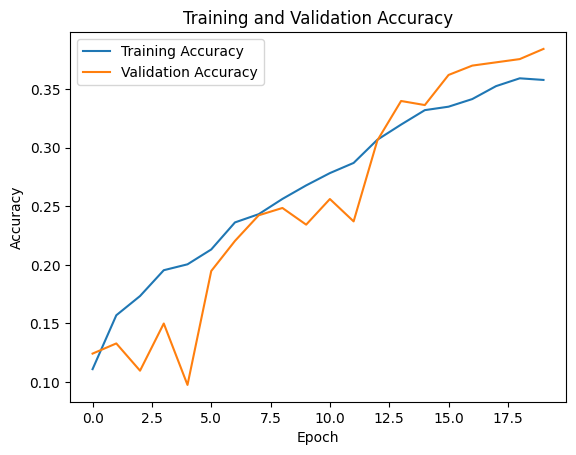

In [15]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.show()

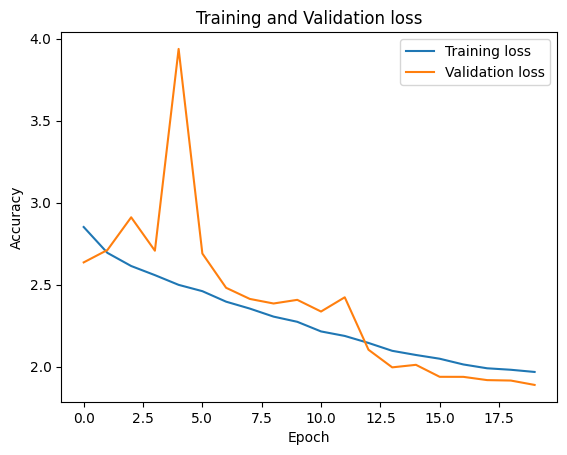

In [16]:
plt.plot(history.history['loss'], label='Training loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation loss')
plt.legend()
plt.show()

In [17]:
loss, accuracy = model.evaluate(test_ds)
print("Test loss:", loss)
print("Test accuracy:", accuracy)

113/113 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.4007 - loss: 1.8801
Test loss: 1.8812886476516724
Test accuracy: 0.40022173523902893


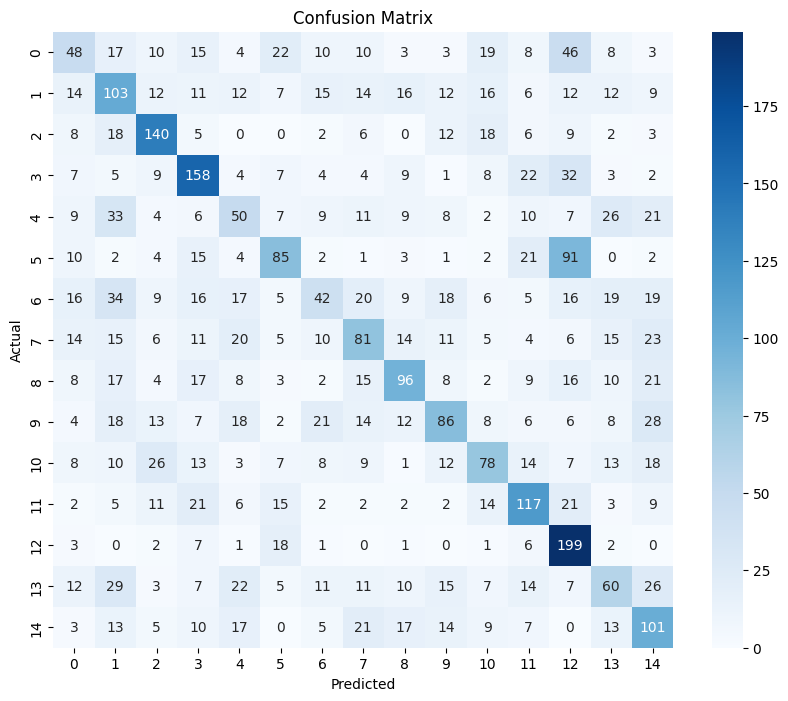

In [18]:
import numpy as np
import tensorflow as tf
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    preds = np.argmax(preds, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(preds)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

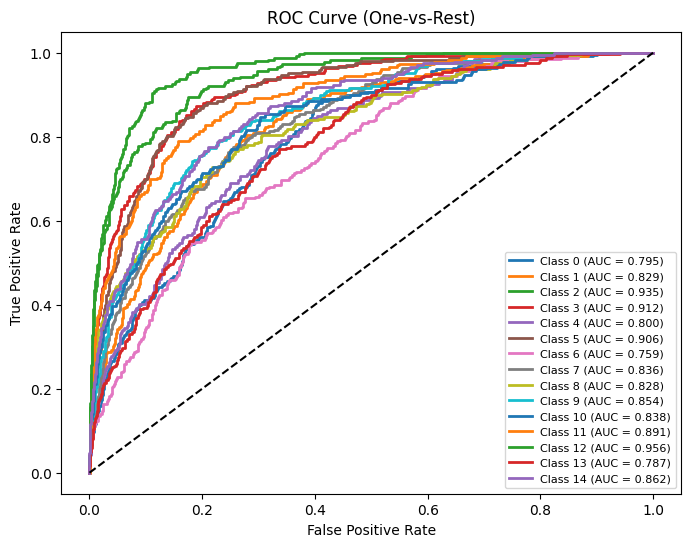

In [19]:
import numpy as np
import tensorflow as tf
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

num_classes = 15

y_true = []
y_pred = []

# collect predictions
for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_pred.extend(preds)
    y_true.extend(labels.numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# convert labels to one-hot
y_true_bin = label_binarize(y_true, classes=np.arange(num_classes))

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# plot
plt.figure(figsize=(8,6))

for i in range(num_classes):
    plt.plot(fpr[i], tpr[i], lw=2,
             label=f'Class {i} (AUC = {roc_auc[i]:.3f})')

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (One-vs-Rest)")
plt.legend(loc="lower right", fontsize=8)
plt.show()